# Dog, Cat & Panda Image Classifier

**AMV10 Visual Analytics — Group 14**

This notebook trains a ResNet-50 classifier on the Dog/Cat/Panda dataset
and exports all artefacts needed by the VA dashboard:
- `export.pkl` — fastai learner for LIME explanations
- `va_export/predictions.csv` — predictions for all images
- Model weights for retraining

Dataset: [Animal Image Dataset (Dog, Cat, Panda)](https://www.kaggle.com/datasets/ashishsaxena2209/animal-image-datasetdog-cat-and-panda)

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

Failed to read module file 'C:\Users\20211233\AppData\Local\Programs\Python\Python311\Lib\pydoc_data\topics.py' for module 'pydoc_data.topics': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\20211233\Documents\GitHub\VA_DR_Dashboard\.venv-1\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\20211233\Documents\GitHub\VA_DR_Dashboard\.venv-1\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\20211233\AppData\Local\Programs\Python\Python311\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1206, in _gcd_import
  File "<frozen importlib._bootstrap>", line

In [2]:
from fastai import *
from fastai.vision import *
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import json
from pathlib import Path
from PIL import Image as PILImage


In [3]:
def seed_everything(seed):
    import random
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

SEED = 42
seed_everything(SEED)
print('cudnn enabled:', torch.backends.cudnn.enabled)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

cudnn enabled: True
CUDA available: False


## 1. Data Loading

The dataset has 3 folders: `dogs/`, `cats/`, `panda/`, each containing ~1000 images.
We build a DataFrame with image paths and labels (0=Cat, 1=Dog, 2=Panda).

In [4]:
# Locate the dataset root folder robustly
# Expected structure:
# DCP/
#   cats/
#   dogs/
#   panda/

def find_data_dir(dirname='DCP'):
    from pathlib import Path

    cwd = Path.cwd().resolve()
    candidates = [
        cwd / dirname,
        cwd.parent / dirname,
        cwd.parent.parent / dirname if cwd.parent != cwd else cwd / dirname,
        Path('/mnt/data') / dirname,
        Path(r'c:/Users/20211233/Documents/GitHub/VA_DR_Dashboard') / dirname,
    ]

    checked = []
    for candidate in candidates:
        candidate = candidate.resolve()
        checked.append(candidate)
        if candidate.is_dir():
            return candidate

    raise FileNotFoundError(
        f"Could not find '{dirname}'. Checked: " + ', '.join(str(p) for p in checked)
    )

DATA_DIR = find_data_dir('DCP')

# Use the folder names directly as labels
TARGET_FOLDERS = ['cats', 'dogs', 'panda']
CLASS_MAP = {name: idx for idx, name in enumerate(TARGET_FOLDERS)}
IDX_TO_CLASS = {idx: name for name, idx in CLASS_MAP.items()}
CLASS_NAMES = IDX_TO_CLASS.copy()   # backward-compatible alias used later in the notebook
IMAGE_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

print('Current working directory:', Path.cwd())
print('Using dataset directory   :', DATA_DIR)

rows = []
for folder_name, label in CLASS_MAP.items():
    folder_path = DATA_DIR / folder_name

    if not folder_path.is_dir():
        print(f'WARNING: {folder_path} not found')
        continue

    image_files = sorted([
        p for p in folder_path.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    ])

    print(f'{folder_name}: {len(image_files)} images found')

    for img_path in image_files:
        rows.append({
            'image_id': img_path.stem,
            # IMPORTANT: store paths relative to DATA_DIR for fastai
            'path': str(img_path.relative_to(DATA_DIR)),
            'abs_path': str(img_path.resolve()),
            'label': label,
            'class_name': folder_name,
            'folder_name': folder_name,
        })

if not rows:
    raise ValueError(
        'No image files were found. Check DATA_DIR and make sure DCP/cats, DCP/dogs, and DCP/panda contain images.'
    )

df = pd.DataFrame(rows)

print(f'Total images: {len(df)}')
print('Columns:', df.columns.tolist())
print('Class distribution:')
print(df['class_name'].value_counts())
display(df.head())

# Quick validation so path issues show up early
missing = [p for p in df['path'].head(10) if not (DATA_DIR / p).is_file()]
if missing:
    print('WARNING: Some sample paths do not resolve correctly:', missing)
else:
    print('Sample path check passed.')


Current working directory: c:\Users\20211233\Documents\GitHub\VA_DR_Dashboard\DCP
Using dataset directory   : C:\Users\20211233\Documents\GitHub\VA_DR_Dashboard\DCP
cats: 1000 images found
dogs: 1000 images found
panda: 1000 images found
Total images: 3000
Columns: ['image_id', 'path', 'abs_path', 'label', 'class_name', 'folder_name']
Class distribution:
class_name
cats     1000
dogs     1000
panda    1000
Name: count, dtype: int64


,image_id,path,abs_path,label,class_name,folder_name
0,cats_00001,cats\cats_00001.jpg,C:\Users\20211233\Documents\GitHub\VA_DR_Dashb...,0,cats,cats
1,cats_00002,cats\cats_00002.jpg,C:\Users\20211233\Documents\GitHub\VA_DR_Dashb...,0,cats,cats
2,cats_00003,cats\cats_00003.jpg,C:\Users\20211233\Documents\GitHub\VA_DR_Dashb...,0,cats,cats
3,cats_00004,cats\cats_00004.jpg,C:\Users\20211233\Documents\GitHub\VA_DR_Dashb...,0,cats,cats
4,cats_00005,cats\cats_00005.jpg,C:\Users\20211233\Documents\GitHub\VA_DR_Dashb...,0,cats,cats


Sample path check passed.


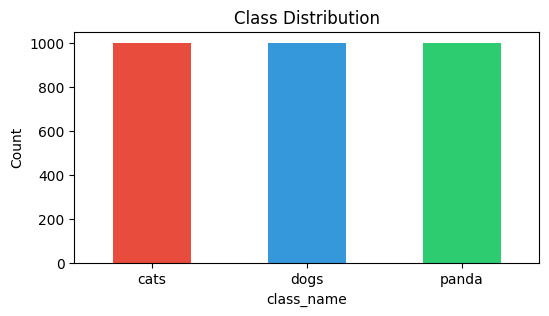

In [5]:
if df.empty:
    print('No data loaded, so class distribution cannot be plotted yet.')
else:
    ax = df['class_name'].value_counts().plot.bar(figsize=(6, 3), color=['#e74c3c', '#3498db', '#2ecc71'])
    plt.title('Class Distribution')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()


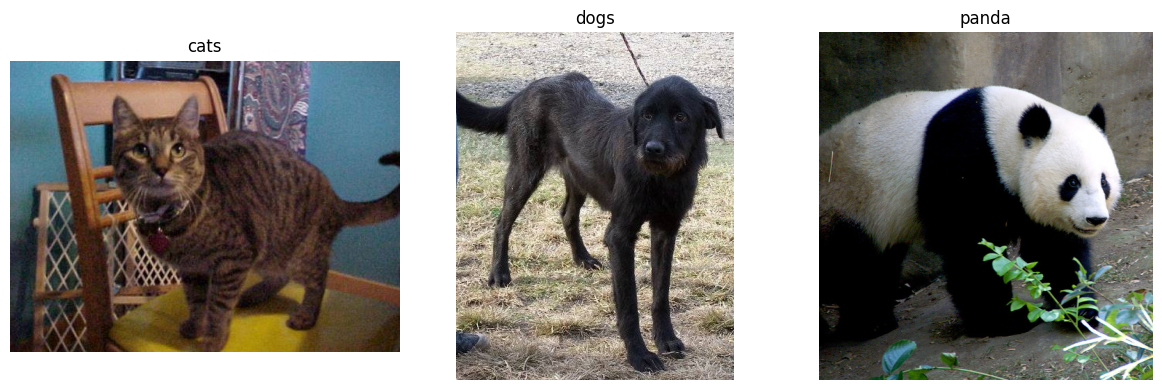

In [6]:
# Show one sample image per class
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, cls in enumerate(TARGET_FOLDERS):
    class_rows = df[df['class_name'] == cls]
    axes[i].axis('off')

    if class_rows.empty:
        axes[i].set_title(f'No image for {cls}')
        continue

    sample = class_rows.iloc[0]
    img = PILImage.open(sample['abs_path']).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(sample['class_name'])

plt.tight_layout()
plt.show()


## 2. Create fastai DataBunch

We use fastai's ImageDataBunch with standard augmentations.
This is a **classification** task (not regression like DR grading).

In [7]:
bs = 64
sz = 224

tfms = get_transforms(
    do_flip=True,
    flip_vert=False,
    max_rotate=15,
    max_warp=0,
    max_zoom=1.1,
    max_lighting=0.2
)

# IMPORTANT:
# df['path'] contains paths relative to DATA_DIR (e.g. 'cats/cats_00002.jpg'),
# so ImageList must use path=DATA_DIR, not './'
data = (
    ImageList.from_df(df=df, path=DATA_DIR, cols='path')
    .split_by_rand_pct(0.2, seed=SEED)
    .label_from_df(cols='class_name')   # uses folder names directly: cats / dogs / panda
    .transform(tfms, size=sz)
    .databunch(bs=bs)
    .normalize(imagenet_stats)
)

print(f'Train: {len(data.train_ds)}, Valid: {len(data.valid_ds)}')
print(f'Classes: {data.classes}')


Train: 2400, Valid: 600
Classes: ['cats', 'dogs', 'panda']


c:\Users\20211233\Documents\GitHub\VA_DR_Dashboard\.venv-1\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


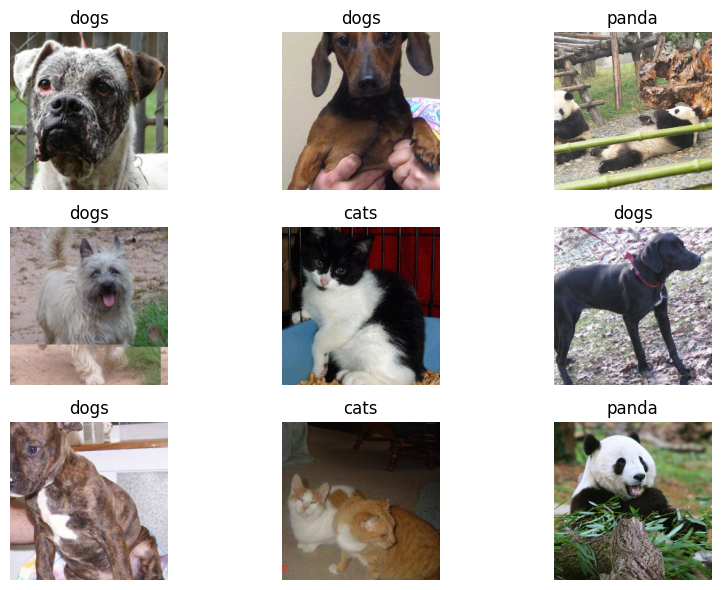

In [8]:
data.show_batch(rows=3, figsize=(9, 6))

## 3. Train ResNet-50

Transfer learning from ImageNet. This is a standard 3-class classification
with cross-entropy loss (fastai default for categorical labels).

In [9]:
learn = cnn_learner(data, base_arch=models.resnet50, metrics=[accuracy])

c:\Users\20211233\Documents\GitHub\VA_DR_Dashboard\.venv-1\Lib\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
c:\Users\20211233\Documents\GitHub\VA_DR_Dashboard\.venv-1\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
learn.lr_find()
learn.recorder.plot(suggestion=True)

epoch,train_loss,valid_loss,accuracy,time


c:\Users\20211233\Documents\GitHub\VA_DR_Dashboard\.venv-1\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
learn.fit_one_cycle(4, max_lr=1e-2)

In [ ]:
learn.recorder.plot_losses()
learn.recorder.plot_metrics()

In [ ]:
learn.unfreeze()
learn.lr_find()
learn.recorder.plot(suggestion=True)

In [ ]:
learn.fit_one_cycle(6, max_lr=slice(1e-6, 1e-3))

In [ ]:
learn.recorder.plot_losses()
learn.recorder.plot_metrics()

In [ ]:
# Save model
learn.export()
learn.save('stage-2')
print('Saved export.pkl and models/stage-2.pth')

## 4. Evaluate

In [ ]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(8, 8), dpi=60)

In [ ]:
interp.plot_top_losses(9, figsize=(12, 12))

## 5. Export artefacts for VA dashboard

We need:
1. `predictions.csv` — image_id, true_class, pred_class, confidence, class_confidences
2. The model is used live by the dashboard (no separate embeddings file needed — hidden layers extracted on the fly)

In [ ]:
EXPORT_DIR = os.path.join('.', 'va_export')
os.makedirs(EXPORT_DIR, exist_ok=True)

# Get predictions for ALL images (train + valid)
all_image_list = ImageList.from_df(df=df, path=DATA_DIR, cols='path')

# Add as test set and predict
learn.data.add_test(all_image_list)
preds, _ = learn.get_preds(ds_type=DatasetType.Test)

# preds is (N, 3) softmax probabilities
probs = preds.numpy()
pred_classes = probs.argmax(axis=1)

# fastai class order should match folder-name labels used in training
fastai_classes = data.classes  # e.g. ['cats', 'dogs', 'panda']
print(f'fastai class order: {fastai_classes}')

# Build class name -> numeric label mapping using folder names
name_to_label = {name: idx for idx, name in IDX_TO_CLASS.items()}
fastai_idx_to_label = [name_to_label[c] for c in fastai_classes]
print(f'fastai index -> our label: {fastai_idx_to_label}')


In [ ]:
# Build predictions DataFrame
predictions = []
for i in range(len(df)):
    row = df.iloc[i]
    prob_vec = probs[i]  # probabilities in fastai class order
    pred_idx = pred_classes[i]
    pred_label = fastai_idx_to_label[pred_idx]

    # Reorder probabilities to our fixed numeric-label order: 0=cats, 1=dogs, 2=panda
    ordered_probs = [float(prob_vec[fastai_classes.index(IDX_TO_CLASS[j])]) for j in range(len(IDX_TO_CLASS))]

    predictions.append({
        'image_id': row['image_id'],
        'path': row['path'],
        'folder_name': row['folder_name'],
        'true_class': int(row['label']),
        'true_class_name': row['class_name'],
        'pred_class': int(pred_label),
        'pred_class_name': IDX_TO_CLASS[int(pred_label)],
        'confidence': round(float(prob_vec.max()), 4),
        'class_confidences': json.dumps([round(p, 4) for p in ordered_probs]),
    })

pred_df = pd.DataFrame(predictions)
print(f'Predictions shape: {pred_df.shape}')
print(f'Accuracy: {(pred_df["true_class"] == pred_df["pred_class"]).mean():.1%}')
pred_df.head()


In [ ]:
# Save predictions
pred_df.to_csv(os.path.join(EXPORT_DIR, 'predictions.csv'), index=False)
print(f'Saved: {EXPORT_DIR}/predictions.csv ({len(pred_df)} rows)')

# Save class mapping
class_info = {
    'class_names': IDX_TO_CLASS,              # numeric label -> folder name
    'label_to_class': CLASS_MAP,              # folder name -> numeric label
    'fastai_classes': fastai_classes,
    'fastai_idx_to_label': fastai_idx_to_label,
    'num_classes': len(IDX_TO_CLASS),
}
with open(os.path.join(EXPORT_DIR, 'class_info.json'), 'w') as f:
    json.dump(class_info, f, indent=2)
print(f'Saved: {EXPORT_DIR}/class_info.json')


In [ ]:
print('\n=== Export Summary ===')
print(f'export.pkl          : model for LIME + dashboard')
print(f'va_export/predictions.csv : {len(pred_df)} predictions')
print(f'va_export/class_info.json : class mapping')
print(f'\nAccuracy: {(pred_df["true_class"] == pred_df["pred_class"]).mean():.1%}')
print(f'\nTo run the dashboard:')
print(f'  1. Copy export.pkl to the dashboard folder')
print(f'  2. Copy va_export/ to the dashboard folder')
print(f'  3. Make sure the images folder is accessible')
print(f'  4. python app_DCP.py')